In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import ast

In [2]:

templates = pd.read_excel('../data/templates.xlsx', sheet_name='Templates')
prompts = pd.read_csv('../data/prompts.csv')

# Extraer el prefijo de cada template (texto antes del primer '[')
templates['prefix'] = templates['prompt'].apply(lambda t: t.split('[')[0])

# Asignar template_id y category a cada prompt según el prefijo
def match_template(prompt):
    for _, row in templates.iterrows():
        if prompt.startswith(row['prefix']):
            return pd.Series({'template_id': row['ID'], 'category': row['category']})
    return pd.Series({'template_id': None, 'category': None})

prompts[['template_id', 'category']] = prompts['prompt'].apply(match_template)

In [3]:
prompts

,prompt,template_id,category
0,"I want to write an article about: ""Common fair...",1,2
1,"I want to write an article about: ""Machine Lea...",1,2
2,"I want to write an article about: ""Evaluation ...",1,2
3,"I want to write an article about: ""Benchmark c...",1,2
4,"I want to write an article about: ""Word embedd...",1,2
...,...,...,...
2130,"Define ""Positive bias"". Include references.",11,1
2131,"Define ""Governance in AI"". Include references.",11,1
2132,"Define ""Intrinsic hallucinations"". Include ref...",11,1
2133,"Define ""Extrinsic hallucinations"". Include ref...",11,1


# Gemini

### URL existe

In [4]:
gemini_url_check = pd.read_csv('../data/analisis/processed/gemini_url_checks_progress.csv')
gemini_url_check['url_check'] = gemini_url_check['url_check'].apply(lambda x: ast.literal_eval(x))
gemini_url_check = gemini_url_check.explode("url_check")
gemini_url_check = gemini_url_check[['prompt', 'url_check']]
gemini_url_check['url_exists'] = gemini_url_check['url_check'].apply(lambda x: x['exists'])
                                                                     
gemini_url_check['url_exists'].value_counts()

url_exists
True     14755
False     1374
Name: count, dtype: int64

In [5]:
gemini_url_check = gemini_url_check.merge(prompts, on = 'prompt')
gemini_url_check.groupby('category')['url_exists'].value_counts()

category  url_exists
1         True          4173
          False          443
2         True          6047
          False          312
3         True          4535
          False          619
Name: count, dtype: int64

In [6]:
gemini_url_check.groupby('category')['url_exists'].value_counts(True)

category  url_exists
1         True          0.904029
          False         0.095971
2         True          0.950936
          False         0.049064
3         True          0.879899
          False         0.120101
Name: proportion, dtype: float64

### Peer reviewed

In [7]:
gemini_results = pd.read_csv('../data/analisis/processed/gemini_url_classify.csv')
gemini_results.drop(columns = [c for c in gemini_results.columns if 'Unnamed' in c], inplace=True)
gemini_results['url'] = gemini_results.url_check.apply(lambda x: ast.literal_eval(x)['url'])
gemini_results['peer_reviewed'] = gemini_results.clasificacion.apply(lambda x: ast.literal_eval(x)['peer_reviewed'])

In [8]:
gemini_results = gemini_results[['prompt', 'url', 'peer_reviewed']]
gemini_results = gemini_results.merge(prompts, on = 'prompt')
gemini_results.peer_reviewed.value_counts()

peer_reviewed
no    12787
sí     1968
Name: count, dtype: int64

In [9]:
gemini_results.groupby('category')['peer_reviewed'].value_counts()

category  peer_reviewed
1         no               3668
          sí                505
2         no               5205
          sí                842
3         no               3914
          sí                621
Name: count, dtype: int64

In [10]:
gemini_results.groupby('category')['peer_reviewed'].value_counts(True)

category  peer_reviewed
1         no               0.878984
          sí               0.121016
2         no               0.860757
          sí               0.139243
3         no               0.863065
          sí               0.136935
Name: proportion, dtype: float64

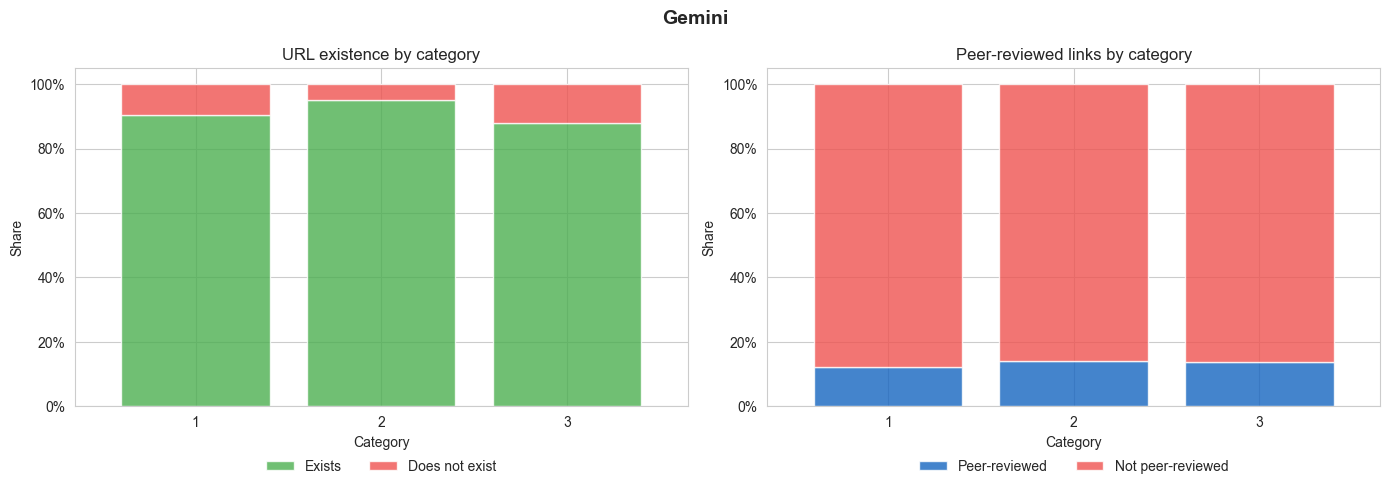

In [11]:
sns.set_style('whitegrid')

gemini_exists_pct = (
    gemini_url_check.groupby('category')['url_exists']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={True: 'Exists', False: 'Does not exist'})
)[['Exists', 'Does not exist']]

gemini_pr_pct = (
    gemini_results.groupby('category')['peer_reviewed']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={'sí': 'Peer-reviewed', 'no': 'Not peer-reviewed'})
)[['Peer-reviewed', 'Not peer-reviewed']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_exists = ['#4CAF50', '#EF5350']
colors_pr = ['#1565C0', '#EF5350']

gemini_exists_pct.plot(kind='bar', stacked=True, ax=ax1, color=colors_exists, width=0.8, alpha=0.8)
ax1.set_title('URL existence by category')
ax1.set_xlabel('Category')
ax1.set_ylabel('Share')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

gemini_pr_pct.plot(kind='bar', stacked=True, ax=ax2, color=colors_pr, width=0.8, alpha=0.8)
ax2.set_title('Peer-reviewed links by category')
ax2.set_xlabel('Category')
ax2.set_ylabel('Share')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

fig.suptitle('Gemini', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mistral

### APA

In [12]:
mistral_apa = pd.read_csv('../data/analisis/processed/mistral_reference_checks.csv')
mistral_apa = mistral_apa[['prompt', 'status']]
mistral_apa = mistral_apa.merge(prompts, on = 'prompt')
mistral_apa['status'].value_counts()

status
review          5586
hallucinated    3103
exists          2810
Name: count, dtype: int64

In [13]:
mistral_apa.groupby('category')['status'].value_counts()

category  status      
1         review          1296
          hallucinated     947
          exists           857
2         review          2370
          exists          1135
          hallucinated     735
3         review          1920
          hallucinated    1421
          exists           818
Name: count, dtype: int64

In [14]:
mistral_apa.groupby('category')['status'].value_counts(True)

category  status      
1         review          0.418065
          hallucinated    0.305484
          exists          0.276452
2         review          0.558962
          exists          0.267689
          hallucinated    0.173349
3         review          0.461649
          hallucinated    0.341669
          exists          0.196682
Name: proportion, dtype: float64

### URL

In [15]:
mistral_url = pd.read_csv('../data/analisis/processed/mistral_classify_complete.csv')
mistral_url['url'] = mistral_url.url_check.apply(lambda x: ast.literal_eval(x)['url'])
mistral_url['existe'] = mistral_url.url_check.apply(lambda x: ast.literal_eval(x)['exists'])
mistral_url = mistral_url[['prompt', 'url', 'existe']]
mistral_url = mistral_url.merge(prompts, on = 'prompt')

In [16]:
mistral_url.groupby('category')['existe'].value_counts(True)

category  existe
1         False     0.682353
          True      0.317647
2         False     0.548780
          True      0.451220
3         False     0.659574
          True      0.340426
Name: proportion, dtype: float64

In [17]:
mistral_url_pr = pd.read_csv('../data/analisis/processed/mistral_classify.csv')
mistral_url_pr['url'] = mistral_url_pr.url_check.apply(lambda x: ast.literal_eval(x)['url'])
mistral_url_pr['peer_reviewed'] = mistral_url_pr.clasificacion.apply(lambda x: ast.literal_eval(x)['peer_reviewed'])
mistral_url_pr = mistral_url_pr[['prompt', 'url', 'peer_reviewed']]
mistral_url_pr = mistral_url_pr.merge(prompts, on = 'prompt')

In [18]:
mistral_url_pr.groupby('category')['peer_reviewed'].value_counts(True)

category  peer_reviewed
1         no               0.875000
          sí               0.125000
2         no               0.613333
          sí               0.386667
3         no               0.895833
          sí               0.104167
Name: proportion, dtype: float64

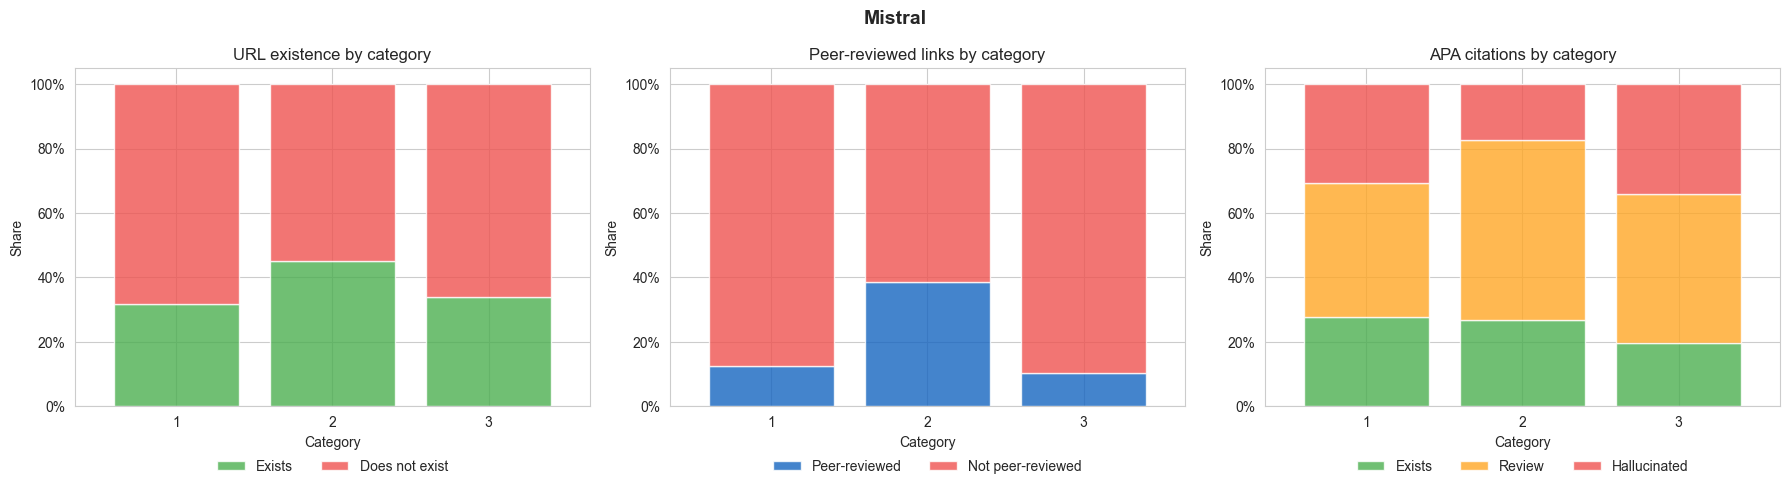

In [19]:
sns.set_style('whitegrid')

mistral_exists_pct = (
    mistral_url.groupby('category')['existe']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={True: 'Exists', False: 'Does not exist'})
)[['Exists', 'Does not exist']]

mistral_pr_pct = (
    mistral_url_pr.groupby('category')['peer_reviewed']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={'sí': 'Peer-reviewed', 'no': 'Not peer-reviewed'})
)[['Peer-reviewed', 'Not peer-reviewed']]

mistral_apa_pct = (
    mistral_apa.groupby('category')['status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={'exists': 'Exists', 'hallucinated': 'Hallucinated', 'review': 'Review'})
)[['Exists', 'Review', 'Hallucinated']]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
colors_exists = ['#4CAF50', '#EF5350']
colors_pr = ['#1565C0', '#EF5350']
colors_apa = ['#4CAF50', '#FFA726', '#EF5350']

mistral_exists_pct.plot(kind='bar', stacked=True, ax=ax1, color=colors_exists, width=0.8, alpha=0.8)
ax1.set_title('URL existence by category')
ax1.set_xlabel('Category')
ax1.set_ylabel('Share')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

mistral_pr_pct.plot(kind='bar', stacked=True, ax=ax2, color=colors_pr, width=0.8, alpha=0.8)
ax2.set_title('Peer-reviewed links by category')
ax2.set_xlabel('Category')
ax2.set_ylabel('Share')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

mistral_apa_pct.plot(kind='bar', stacked=True, ax=ax3, color=colors_apa, width=0.8, alpha=0.8)
ax3.set_title('APA citations by category')
ax3.set_xlabel('Category')
ax3.set_ylabel('Share')
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)

fig.suptitle('Mistral', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## GPT

### URL existe

In [20]:
gpt1 = pd.read_csv('../data/analisis/processed/gpt_url_checks.csv')
gpt2 = pd.read_csv('../data/analisis/processed/gpt_web_search_url_checks.csv')

In [21]:
gpt1.shape, gpt2.shape

((2135, 6), (1042, 6))

In [22]:
gpt1 = gpt1[~gpt1['prompt'].isin(gpt2['prompt'])]

In [23]:
gpt1['url_check'] = gpt1['url_checks'].apply(lambda x: ast.literal_eval(x))
gpt1 = gpt1.explode("url_check")
gpt1 = gpt1[['prompt', 'url_check']]
def get_exists(url_check):
    try:
        return url_check['exists']
    except:
        return None

gpt1['url_exists'] = gpt1['url_check'].apply(get_exists)
gpt1.url_exists.value_counts()


url_exists
True     3211
False     674
Name: count, dtype: int64

In [24]:
gpt2['url_check'] = gpt2['url_checks'].apply(lambda x: ast.literal_eval(x))
gpt2 = gpt2.explode("url_check")
gpt2 = gpt2[['prompt', 'url_check']]
gpt2['url_exists'] = gpt2['url_check'].apply(get_exists)

gpt2.url_exists.value_counts()

url_exists
True     11147
False     3721
Name: count, dtype: int64

In [25]:
gpt = pd.concat([gpt1, gpt2], ignore_index=True)

In [26]:
gpt

,prompt,url_check,url_exists
0,"I want to write an article about: ""Common fair...",{'url': 'https://jmlr.org/beta/papers/v24/22-1...,True
1,"I want to write an article about: ""Common fair...",{'url': 'https://arxiv.org/abs/1902.04783?utm_...,True
2,"I want to write an article about: ""Common fair...",{'url': 'https://arxiv.org/abs/1711.05144?utm_...,True
3,"I want to write an article about: ""Common fair...",{'url': 'https://arxiv.org/abs/2107.04642?utm_...,True
4,"I want to write an article about: ""Common fair...",{'url': 'https://www.emergentmind.com/papers/1...,True
...,...,...,...
18867,"Define ""Rebound effect"". Include references.",{'url': 'https://quickonomics.com/terms/reboun...,True
18868,"Define ""Rebound effect"". Include references.",{'url': 'https://www.collinsdictionary.com/dic...,False
18869,"Define ""Rebound effect"". Include references.",{'url': 'https://www.sciencedirect.com/topics/...,False
18870,"Define ""Rebound effect"". Include references.",{'url': 'https://sustainability.bonares.de/sus...,False


In [27]:
gpt_url_check = gpt.merge(prompts, on = 'prompt')
gpt_url_check.groupby('category')['url_exists'].value_counts()

category  url_exists
1         True          5347
          False         1620
2         True          1893
          False          396
3         True          7118
          False         2379
Name: count, dtype: int64

In [28]:
gpt_url_check.groupby('category')['url_exists'].value_counts(True)

category  url_exists
1         True          0.767475
          False         0.232525
2         True          0.826999
          False         0.173001
3         True          0.749500
          False         0.250500
Name: proportion, dtype: float64

### Peer reviewed

In [29]:
gpt_url_check['url'] = gpt_url_check.url_check.apply(lambda x: x['url'] if pd.notnull(x) else None)
#gpt_url_check

In [30]:
gpt_url_check.head()

,prompt,url_check,url_exists,template_id,category,url
0,"I want to write an article about: ""Common fair...",{'url': 'https://jmlr.org/beta/papers/v24/22-1...,True,1,2,https://jmlr.org/beta/papers/v24/22-1511.html?...
1,"I want to write an article about: ""Common fair...",{'url': 'https://arxiv.org/abs/1902.04783?utm_...,True,1,2,https://arxiv.org/abs/1902.04783?utm_source=op...
2,"I want to write an article about: ""Common fair...",{'url': 'https://arxiv.org/abs/1711.05144?utm_...,True,1,2,https://arxiv.org/abs/1711.05144?utm_source=op...
3,"I want to write an article about: ""Common fair...",{'url': 'https://arxiv.org/abs/2107.04642?utm_...,True,1,2,https://arxiv.org/abs/2107.04642?utm_source=op...
4,"I want to write an article about: ""Common fair...",{'url': 'https://www.emergentmind.com/papers/1...,True,1,2,https://www.emergentmind.com/papers/1609.07236...


In [31]:
import pandas as pd
import sys
sys.path.append("../src/process_results")

from classify_urls import process_urls

urls_list = gpt_url_check[gpt_url_check.url_exists == True]["url"].drop_duplicates().tolist()

In [32]:
results = process_urls(urls_list, workers=8)

[██████████████████████████████] 6960/6960  


In [33]:
classified_df = pd.DataFrame(results)
classified_df = classified_df.merge(gpt_url_check[["prompt", "template_id", "category", "url"]], on="url", how="left")

In [34]:
classified_df

,url,peer_reviewed,confianza,razon,doi,prompt,template_id,category
0,https://jmlr.org/beta/papers/v24/22-1511.html?...,sí,baja,Heurística: patrón '/paper[s]?/' en URL,,"I want to write an article about: ""Common fair...",1,2
1,https://jmlr.org/beta/papers/v24/22-1511.html?...,sí,baja,Heurística: patrón '/paper[s]?/' en URL,,What is the current consensus on the statement...,4,2
2,https://jmlr.org/beta/papers/v24/22-1511.html?...,sí,baja,Heurística: patrón '/paper[s]?/' en URL,,"What evidence supports the claim that ""Common ...",5,3
3,https://jmlr.org/beta/papers/v24/22-1511.html?...,sí,baja,Heurística: patrón '/paper[s]?/' en URL,,"Sources pro or against the statement ""Common f...",7,1
4,https://jmlr.org/beta/papers/v24/22-1511.html?...,sí,baja,Heurística: patrón '/paper[s]?/' en URL,,I'm analyzing this article https://papers.nips...,10,2
...,...,...,...,...,...,...,...,...
14398,https://www.taylorfrancis.com/chapters/oa-edit...,no,media,DOI no encontrado en Crossref,10.4324/9781003584056-24/rebound-effects-eva-a...,"Define ""Rebound effect"". Include references.",11,1
14399,https://energiewende.bundeswirtschaftsminister...,no,baja,Sin señales académicas detectadas,,"Define ""Rebound effect"". Include references.",11,1
14400,https://www.colcomfdn.org/rebound-effect/?utm_...,no,baja,Sin señales académicas detectadas,,"Define ""Rebound effect"". Include references.",11,1
14401,https://quickonomics.com/terms/rebound-effect/...,no,baja,Sin señales académicas detectadas,,"Define ""Rebound effect"". Include references.",11,1


In [35]:
gpt_results.shape, gpt_results.drop_duplicates().shape

NameError: name 'gpt_results' is not defined

In [85]:
18753-14403

4350

In [36]:
gpt_results = classified_df[['prompt', 'url', 'peer_reviewed']]
gpt_results = gpt_results.merge(prompts, on = 'prompt')
gpt_results.peer_reviewed.value_counts()

peer_reviewed
no    10707
sí     3696
Name: count, dtype: int64

In [37]:
gpt_results.drop_duplicates().peer_reviewed.value_counts()

peer_reviewed
no    10707
sí     3696
Name: count, dtype: int64

In [38]:
gpt_results.groupby('category')['peer_reviewed'].value_counts()

category  peer_reviewed
1         no               4180
          sí               1185
2         no               1538
          sí                362
3         no               4989
          sí               2149
Name: count, dtype: int64

In [39]:
gpt_results.groupby('category')['peer_reviewed'].value_counts(True)

category  peer_reviewed
1         no               0.779124
          sí               0.220876
2         no               0.809474
          sí               0.190526
3         no               0.698935
          sí               0.301065
Name: proportion, dtype: float64

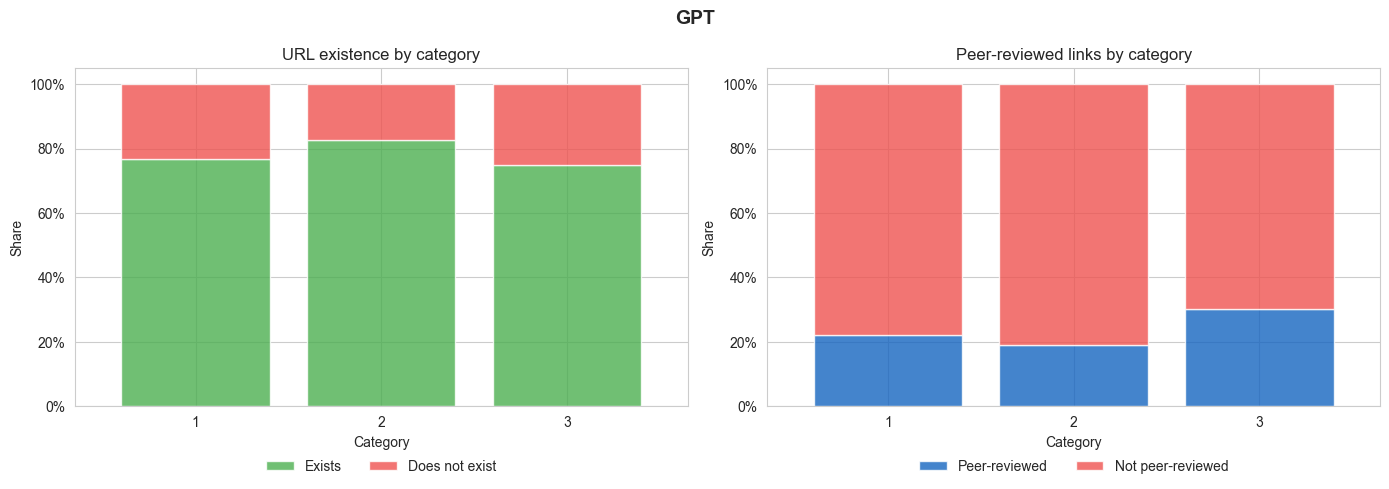

In [40]:
sns.set_style('whitegrid')

gpt_exists_pct = (
    gpt_url_check.groupby('category')['url_exists']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={True: 'Exists', False: 'Does not exist'})
)[['Exists', 'Does not exist']]

gpt_pr_pct = (
    gpt_results.groupby('category')['peer_reviewed']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={'sí': 'Peer-reviewed', 'no': 'Not peer-reviewed'})
)[['Peer-reviewed', 'Not peer-reviewed']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_exists = ['#4CAF50', '#EF5350']
colors_pr = ['#1565C0', '#EF5350']

gpt_exists_pct.plot(kind='bar', stacked=True, ax=ax1, color=colors_exists, width=0.8, alpha=0.8)
ax1.set_title('URL existence by category')
ax1.set_xlabel('Category')
ax1.set_ylabel('Share')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

gpt_pr_pct.plot(kind='bar', stacked=True, ax=ax2, color=colors_pr, width=0.8, alpha=0.8)
ax2.set_title('Peer-reviewed links by category')
ax2.set_xlabel('Category')
ax2.set_ylabel('Share')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

fig.suptitle('GPT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()